In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test)= datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [6]:
y_train= y_train.reshape(-1, )
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [7]:
classes= ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [8]:
def plot_sample(X, y, index):
    plt.figure(figsize= (15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

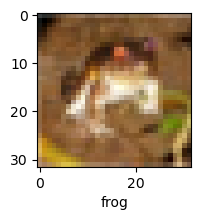

In [9]:
plot_sample(X_train, y_train, 0)

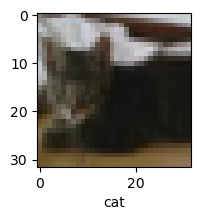

In [10]:
plot_sample(X_train, y_train, 9)

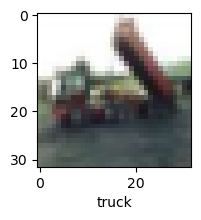

In [11]:
plot_sample(X_train, y_train, 2)

In [12]:
X_train= X_train/255
X_test= X_test/255

In [13]:
ann= models.Sequential([
    layers.Flatten(input_shape= (32, 32, 3)),
    layers.Dense(3000, activation= 'relu'),
    layers.Dense(1000, activation= 'relu'),
    layers.Dense(10, activation= 'sigmoid'),
])

ann.compile(optimizer= 'SGD', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'])
ann.fit(X_train, y_train, epochs= 5)

C:\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 63ms/step - accuracy: 0.3524 - loss: 1.8135
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 62ms/step - accuracy: 0.4288 - loss: 1.6219
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 65ms/step - accuracy: 0.4551 - loss: 1.5419
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 67ms/step - accuracy: 0.4757 - loss: 1.4817
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.4960 - loss: 1.4317


In [14]:
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4699 - loss: 1.4697


[1.4696811437606812, 0.4699000120162964]

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred= ann.predict(X_test)
y_pred_classes= [np.argmax(element) for element in y_pred]
print("Classification report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Classification report: 
               precision    recall  f1-score   support

           0       0.55      0.59      0.57      1000
           1       0.71      0.44      0.54      1000
           2       0.43      0.17      0.25      1000
           3       0.35      0.33      0.33      1000
           4       0.31      0.65      0.42      1000
           5       0.39      0.35      0.37      1000
           6       0.54      0.45      0.49      1000
           7       0.52      0.56      0.54      1000
           8       0.54      0.68      0.60      1000
           9       0.60      0.48      0.53      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.47     10000
weighted avg       0.49      0.47      0.47     10000



In [17]:
cnn= models.Sequential([
    layers.Conv2D(filters= 32, kernel_size= (3, 3), activation= 'relu', input_shape= (32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters= 64, kernel_size= (3, 3), activation= 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(input_shape= (32, 32, 3)),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(10, activation= 'softmax'),
])

C:\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
cnn.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'])
cnn.fit(X_train, y_train, epochs= 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.4774 - loss: 1.4479
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6142 - loss: 1.1057
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6624 - loss: 0.9779
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.6903 - loss: 0.8942
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7151 - loss: 0.8255
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7317 - loss: 0.7719
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7488 - loss: 0.7253
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7626 - loss: 0.6835
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7760 - loss: 0.6421
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7889 - loss: 0.6036


In [19]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7006 - loss: 0.9131


[0.9131345748901367, 0.7006000280380249]

In [21]:
y_test= y_test.reshape(-1, )
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

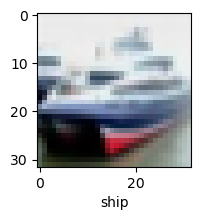

In [22]:
plot_sample(X_test, y_test, 1)

In [23]:
y_pred= cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[5.4770851e-05, 1.5342501e-07, 3.7964289e-03, 9.8142713e-01,
        3.9306510e-04, 3.7866337e-03, 9.4450805e-03, 4.1247331e-06,
        1.0924515e-03, 1.7930940e-07],
       [9.2001261e-05, 3.5323980e-03, 1.1498144e-07, 5.6432352e-08,
        6.3999495e-10, 1.1311549e-09, 1.5031314e-09, 3.1010530e-10,
        9.9636972e-01, 5.6251661e-06],
       [1.1901503e-01, 1.5306249e-01, 1.2903083e-03, 5.6125252e-03,
        2.8867128e-03, 1.3715627e-03, 2.0241800e-04, 6.9005843e-03,
        4.6261117e-01, 2.4704716e-01],
       [9.5419025e-01, 2.8595181e-02, 1.4055093e-03, 2.7688034e-04,
        1.8933720e-03, 5.0698964e-06, 3.4117569e-05, 4.2639405e-04,
        1.2937585e-02, 2.3564485e-04],
       [3.5711159e-07, 9.4146333e-07, 8.3421841e-03, 1.5078837e-02,
        4.1477025e-02, 2.3468337e-03, 9.3242538e-01, 1.4729198e-07,
        3.2811653e-04, 1.1824275e-07]], dtype=float32)

In [24]:
y_classes= [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [25]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

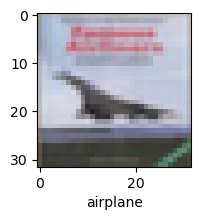

In [30]:
plot_sample(X_test, y_test, 3)

In [31]:
classes[y_classes[3]]

'airplane'

In [33]:
print("Classification report: \n", classification_report(y_test, y_classes))

Classification report: 
               precision    recall  f1-score   support

           0       0.78      0.66      0.71      1000
           1       0.84      0.78      0.81      1000
           2       0.55      0.64      0.59      1000
           3       0.54      0.56      0.55      1000
           4       0.61      0.70      0.65      1000
           5       0.65      0.57      0.61      1000
           6       0.79      0.78      0.78      1000
           7       0.78      0.69      0.73      1000
           8       0.74      0.86      0.80      1000
           9       0.79      0.76      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000

